In [1]:
import numpy as np
import matplotlib.pyplot as plt
import JG_Wrapper as rev
import sys
import ctypes
import time
import os

sys.path.append('/project/6004619/jgoodeve/JG_Wrapper/JG_CHORD_Imaging_Wrapper/JG_Wrapper')

In [2]:
u,w = rev.gen_image_u((0,49),1/85,(400,200))

A = rev.FFT_noise_sim(22, 24, 8.3, 6.5, 49, 49, 1, 200e3, 30, 6000, 1, 1300e6, (400,200), 1/85, 6)

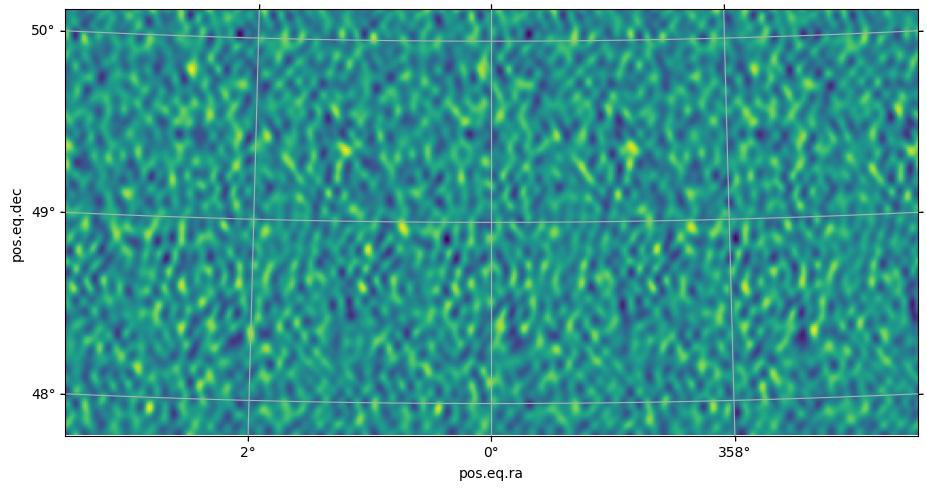

In [3]:
fig, ax = plt.subplots(subplot_kw=dict(projection=w),figsize = (11,7))
ax.imshow(A)
ax.coords['ra'].set_major_formatter('dd')
ax.coords['dec'].set_major_formatter('dd')
plt.grid()

### Actually Imaging

In [4]:
omega = 2*np.pi/(3600*24) ## in per s

imcenter = (0,0) ## RA, dec of the centre of the image. This also sets the WCS
cellsize = 1/85 ## image pixel sidelength in deg
imsize = (1600,600) ## pixels on a side
imparams = np.array([imcenter[0],imcenter[1],cellsize,imsize])
u,w = rev.gen_image_u(imcenter,cellsize,imsize) ## first argument is ra/dec in deg as tuple, then cellsize, then imsize. Angles in deg

### OBSERVATION SPECIFICS ### (set these; some are calculated for you from others)

M = 22 ## how many antennae in NS direction
N = 24 ## how many antennae in EW direction
L1 = 8.5 ## antenna spacing delta in NS direction (in m)
L2 = 6.3 ## antenna spacing delta in EW direction (in m)
chord_lat = 49.3 ## chord zenith declination (deg)
ant_diam = 6.0 ## antenna diameter (in m)
dtau = 30 ## integration time (in s)
dphi = 180/np.pi*omega*dtau ## degrees of RA per time step
centre_phi_RA_deg = 0 ## central RA, in deg, for the set of integrations
N_times = 160 ## number of integrations to do
initial_phi_offset = (N_times-1)/2*dphi ## Calculated for you. Don't worry about this

survey_dec = 0 ## Sets CHORD survey declination (degrees)
nu1 = 1300e6 ## first channel frequency (Hz)
nu2 = 1500e6  ## last channel frequency (Hz)
nchannels = 2 ## number of channels
dnu = (nu2-nu1)/nchannels ## (computed for you)
eta = 1 ## antenna power collection efficiency
SEFD = 6000 ## per antenna system equivalent flux density (in Jy)

frequencies = np.linspace(nu1,nu2,nchannels)
wavelengths = 3e8/frequencies

/tmp/ipykernel_1310072/3944862791.py:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  imparams = np.array([imcenter[0],imcenter[1],cellsize,imsize])


### WHAT SOURCE FIELDS TO INCLUDE?

In [5]:
include_bright_background = False ## include the FIRST-derived, 'bright' background (>1mJy)
include_faint_background = False ## include the randomly generated 'faint' background (10uJy - 1mJy)

### GENERATING THE SELECTED BACKGROUNDS

In [6]:
source_us_orig = np.zeros((1,3)) ## a source with zero brightness, so this object always exists even if backgrounds are turned off
source_us_orig[0][0] = 1 ## so that this is actually a unit vector
spectra_orig = np.zeros((1,len(frequencies)))

if include_bright_background:

    ## leave this block alone, it reads in the sky background file ##
    background_data = np.load('JG_Wrapper/SKYMODEL_RA_dec_F_sidx.npz')
    RA = background_data['RA']
    Dec = background_data['dec']
    FJy = background_data['FmJy']/1000
    spec_idx = background_data['spec_idx']
    bright_source_us,F,s = rev.return_close_sources(centre_phi_RA_deg,survey_dec,initial_phi_offset,N_times,dphi,RA,Dec,FJy,spec_idx)
    source_us_orig = np.concatenate((source_us_orig,bright_source_us),axis = 0)
    spectra_orig = np.concatenate((spectra_orig,rev.get_spectra(frequencies,F,s)),axis = 0) ## generates spectra for all background objects

if include_faint_background:

    ### generate the faint background sources:
    phi1 = centre_phi_RA_deg - 0.5*N_times*dphi - 2/np.cos(np.deg2rad(imcenter[1]))
    phi2 = centre_phi_RA_deg + 0.5*N_times*dphi + 2/np.cos(np.deg2rad(imcenter[1]))

    if np.abs(phi2-phi1) > 360:
        phi2 = 360
        phi1 = 0
    faint_u, faint_spectra = rev.gen_faint_background(120,-1.85,0.1,1,
        phi1,
        phi2,
        imcenter[1]-2,
        np.min((imcenter[1]+2,90)),frequencies)
    source_us_orig = np.concatenate((source_us_orig,faint_u),axis = 0)
    spectra_orig = np.concatenate((spectra_orig,faint_spectra),axis = 0) ## generates spectra for all background objects

### THIS IS WHERE YOU WOULD APPEND YOUR OWN SOURCES ###
### THE FINAL ARRAYS MUST BE CALLED 'spectra' AND   ###
### 'source_us' AS SHOWN BELOW. APPEND YOUR OWN     ###
### SOURCES, GENERATED AS YOU'D LIKE, HERE          ###

user_source_us = rev.u_vec([0],[49])
user_spectra = 5/1000*np.ones((1,len(frequencies)))

source_us = np.concatenate((source_us_orig, user_source_us),axis = 0)[1:]
spectra = np.concatenate((spectra_orig, user_spectra),axis = 0)[1:]

#######################################################
#######################################################

In [7]:
len(spectra)

1

### CHORD SETUP

In [8]:
chord_thetas = np.asarray([np.deg2rad(90-survey_dec)], dtype=ctypes.c_float)
cp = rev.chordParams(thetas = rev.unpackArraytoStruct(chord_thetas),
                centre_phi = np.deg2rad(centre_phi_RA_deg),
                initial_phi_offset = np.deg2rad(initial_phi_offset),
                m1=M, m2=N, L1=L1, L2=L2, CHORD_zenith_dec = chord_lat, D = ant_diam,
                delta_tau = dtau, time_samples=N_times)

### RUN THE CODE

In [9]:
t1 = time.time()

dirtymap = rev.dirtymap_simulator_wrapper (u.astype(ctypes.c_float), wavelengths.astype(ctypes.c_float), source_us, spectra, 1e-9, cp)
dirtymap = dirtymap.reshape(imsize[1],imsize[0],len(frequencies))

t2 = time.time()

print("Dirtymap simulator took", t2-t1, " seconds")

Device count: 1
Dirtymap simulator took 0.486616849899292  seconds


### MAKE CORRESPONDING NOISE

In [10]:
t0 = time.time()

noise = dirtymap.copy()
for i in range(len(frequencies)):
    noise[:,:,i] = rev.FFT_noise_sim(M,N,L1,L2,chord_lat,survey_dec,N_times,dnu,dtau,SEFD,eta,frequencies[i],imsize,cellsize,ant_diam,applybeam = False)
    
print(time.time()-t0)
    

0.17305350303649902


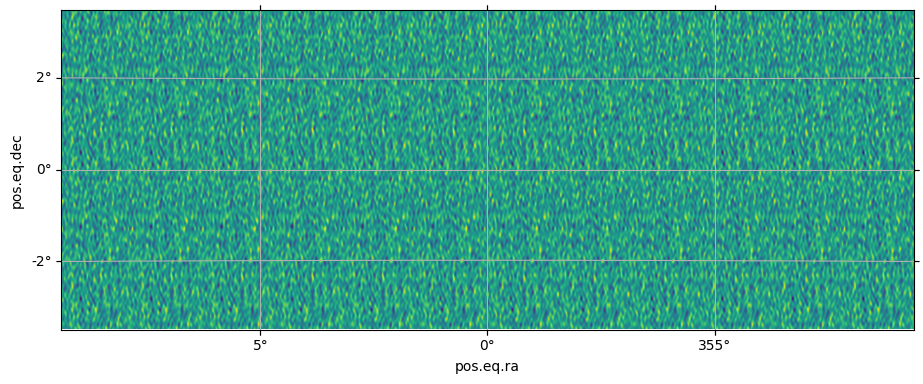

In [11]:
fig, ax = plt.subplots(subplot_kw=dict(projection=w),figsize = (11,7))
ax.imshow(noise[:,:,0])
ax.coords['ra'].set_major_formatter('dd')
ax.coords['dec'].set_major_formatter('dd')
plt.grid()

### RECOVER THE BEAM

In [12]:
A_beam,B_beam = rev.recover_net_beam(u, centre_phi_RA_deg, initial_phi_offset, dphi, N_times, frequencies, survey_dec, imsize, antenna_diam = ant_diam)

In [13]:
dirtymap,noise,A_beam = rev.normalize(dirtymap,noise,A_beam,B_beam,frequencies,M,N,beamthresh = 0.001)

In [14]:
np.max(spectra)

0.005

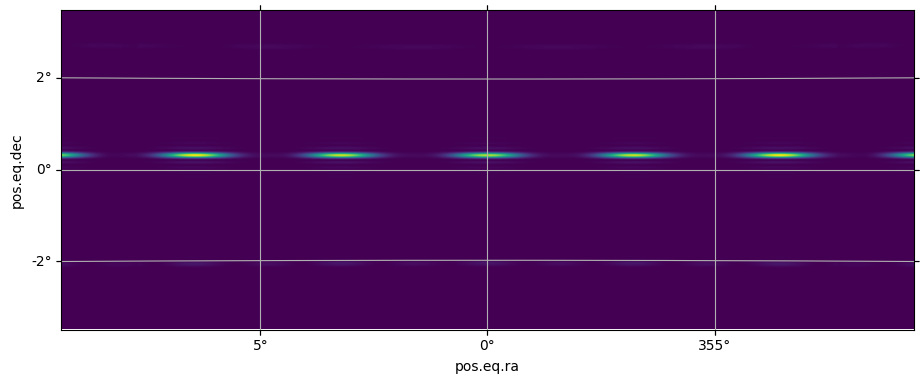

In [15]:
fig, ax = plt.subplots(subplot_kw=dict(projection=w),figsize = (11,7))
ax.imshow(dirtymap[:,:,0])
ax.coords['ra'].set_major_formatter('dd')
ax.coords['dec'].set_major_formatter('dd')
plt.grid()

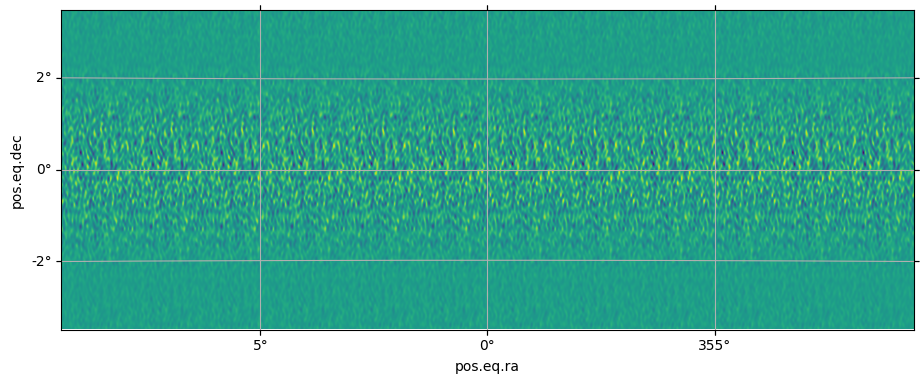

In [16]:
fig, ax = plt.subplots(subplot_kw=dict(projection=w),figsize = (11,7))
ax.imshow(noise[:,:,0])
ax.coords['ra'].set_major_formatter('dd')
ax.coords['dec'].set_major_formatter('dd')
plt.grid()